# Democracy backsliding risk model (ERT + World Bank)
Run top-to-bottom.


In [71]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV


## 1) Download + load ERT (V-Dem Episodes of Regime Transformation)


In [72]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

ERT_URL = "https://raw.githubusercontent.com/vdeminstitute/ERT/master/inst/ert.csv"
ERT_PATH = DATA_DIR / "ert.csv"

def download_if_missing(url: str, dest: Path, overwrite: bool = False) -> None:
    if dest.exists() and not overwrite:
        return
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        tmp = dest.with_suffix(dest.suffix + ".tmp")
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
        tmp.replace(dest)

download_if_missing(ERT_URL, ERT_PATH, overwrite=False)

ert_raw = pd.read_csv(ERT_PATH)
print("ERT rows/cols:", ert_raw.shape)
display(ert_raw.head())


ERT rows/cols: (19678, 42)


,Unnamed: 0,country_id,country_text_id,country_name,year,v2x_regime,v2x_polyarchy,v2x_polyarchy_codelow,v2x_polyarchy_codehigh,reg_start_year,...,aut_ep_start_year,aut_ep_end_year,aut_pre_ep_year,aut_ep_termination,aut_ep_prch,aut_ep_pbr,aut_ep_subreg,aut_ep_outcome,aut_ep_outcome_agg,aut_ep_censored
0,1,3,MEX,Mexico,1900,0.0,0.124,0.112,0.134,1900.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,0,0,0
1,2,3,MEX,Mexico,1901,0.0,0.108,0.096,0.119,1900.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,0,0,0
2,3,3,MEX,Mexico,1902,0.0,0.108,0.096,0.119,1900.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,0,0,0
3,4,3,MEX,Mexico,1903,0.0,0.108,0.096,0.119,1900.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,0,0,0
4,5,3,MEX,Mexico,1904,0.0,0.108,0.096,0.119,1900.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,0,0,0


## 2) Standardize key ERT columns (ISO3 `country_key`, `year`, `v2x_regime`)
We compute the *label* ourselves as: democracy this year → non-democracy next year.


In [73]:
def pick_col(df, candidates):
    # exact / case-insensitive match
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    # normalized match (remove underscores/spaces)
    import re
    norm = {re.sub(r'[_\s]+','',c.lower()): c for c in df.columns}
    for cand in candidates:
        key = re.sub(r'[_\s]+','',cand.lower())
        if key in norm:
            return norm[key]
    return None

col_year    = pick_col(ert_raw, ["year"])
col_iso3    = pick_col(ert_raw, ["country_text_id", "country_textid", "iso3", "iso3c", "country_code"])
col_cname   = pick_col(ert_raw, ["country_name", "country"])
col_regime  = pick_col(ert_raw, ["v2x_regime"])

print("Detected columns:")
print("  year:", col_year)
print("  iso3:", col_iso3)
print("  country_name:", col_cname)
print("  v2x_regime:", col_regime)

if col_year is None or col_regime is None:
    raise ValueError("ERT missing required columns. Need at least: year, v2x_regime.")

ert = ert_raw.copy()
ert["year"] = pd.to_numeric(ert[col_year], errors="coerce").astype("Int64")
ert["v2x_regime"] = pd.to_numeric(ert[col_regime], errors="coerce")

# Merge key: prefer ISO3-like if present; otherwise country name (not recommended)
if col_iso3 is not None:
    ert["country_key"] = ert[col_iso3].astype(str).str.strip().str.upper()
else:
    ert["country_key"] = ert[col_cname].astype(str).str.strip().str.upper()

# Filter years where WB data is mostly available; adjust as needed
ert = ert[(ert["year"] >= 1950) & (ert["year"] <= 2025)].copy()
ert = ert[ert["country_key"].notna() & (ert["country_key"] != "")].copy()

print("ERT cleaned:", ert.shape)
display(ert[["country_key","year","v2x_regime"]].head())


Detected columns:
  year: year
  iso3: country_text_id
  country_name: country_name
  v2x_regime: v2x_regime
ERT cleaned: (12467, 43)


,country_key,year,v2x_regime
50,MEX,1950,1.0
51,MEX,1951,1.0
52,MEX,1952,1.0
53,MEX,1953,1.0
54,MEX,1954,1.0


## 3) Fetch World Bank indicators (API), build WB panel, and engineer WB-derived features


In [74]:
WB_BASE = "https://api.worldbank.org/v2"

INDICATORS = {
    # core macro
    "gdp_growth": "NY.GDP.MKTP.KD.ZG",
    "inflation_cpi": "FP.CPI.TOTL.ZG",
    "unemployment": "SL.UEM.TOTL.ZS",
    "gdp_pc_current_usd": "NY.GDP.PCAP.CD",

    # inequality (sparse)
    "gini": "SI.POV.GINI",

    # debt stress
    "ext_debt_gni": "DT.DOD.DECT.GN.ZS",
    "debt_service_exports": "DT.TDS.DECT.EX.ZS",

    # living standards proxy
    "consumption_pc_growth": "NE.CON.PRVT.PC.KD.ZG",

    # structural / sociological proxies
    "resource_rents_gdp": "NY.GDP.TOTL.RT.ZS",
    "pop_total": "SP.POP.TOTL",
    "pop_urban": "SP.URB.TOTL",

    # youth pop pieces (derive 15–24 share ourselves)
    "pop_1519_m": "SP.POP.1519.MA",
    "pop_1519_f": "SP.POP.1519.FE",
    "pop_2024_m": "SP.POP.2024.MA",
    "pop_2024_f": "SP.POP.2024.FE",

    # youth unemployment
    "youth_unemployment": "SL.UEM.1524.ZS",

    # migration (absolute; derive per-1,000)
    "net_migration": "SM.POP.NETM",
}

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "wb-panel-builder/1.0"})

def _raise_if_wb_error(payload, indicator_code):
    if isinstance(payload, list) and len(payload) >= 1 and isinstance(payload[0], dict) and "message" in payload[0]:
        raise ValueError(f"World Bank API error for {indicator_code}: {payload[0]['message']}")

def wb_fetch_indicator(indicator_code, per_page=20000, sleep_s=0.1, timeout=120):
    url = f"{WB_BASE}/country/all/indicator/{indicator_code}"
    page = 1
    out = []

    while True:
        params = {"format": "json", "per_page": per_page, "page": page}
        r = SESSION.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        data = r.json()

        _raise_if_wb_error(data, indicator_code)

        if not isinstance(data, list) or len(data) < 2 or not isinstance(data[0], dict):
            raise ValueError(f"Unexpected response shape for {indicator_code}: {str(data)[:300]}")

        meta = data[0]
        records = data[1] or []

        for rec in records:
            iso3 = rec.get("countryiso3code")
            year = rec.get("date")
            val = rec.get("value")

            if not iso3:
                continue
            if year is None:
                continue
            try:
                y = int(year)
            except Exception:
                continue

            out.append((iso3.strip().upper(), y, val))

        pages = meta.get("pages")
        if pages is None:
            if not records:
                break
        else:
            try:
                pages = int(pages)
            except Exception:
                pages = page
            if page >= pages:
                break

        page += 1
        time.sleep(sleep_s)

    df = pd.DataFrame(out, columns=["iso3", "year", indicator_code])
    df[indicator_code] = pd.to_numeric(df[indicator_code], errors="coerce")
    return df

def build_wb_panel(indicators, sleep_s=0.15):
    frames = []
    for name, code in indicators.items():
        print(f"Fetching {name}: {code}")
        df = wb_fetch_indicator(code, sleep_s=sleep_s).rename(columns={code: name})
        frames.append(df)

    panel = frames[0]
    for df in frames[1:]:
        panel = panel.merge(df, on=["iso3", "year"], how="outer")

    panel = panel.sort_values(["iso3", "year"]).reset_index(drop=True)
    return panel

wb = build_wb_panel(INDICATORS)

# Derived WB features (keep shares as PERCENT 0..100 for interpretability)
pop_cols = ["pop_1519_m", "pop_1519_f", "pop_2024_m", "pop_2024_f"]
for c in pop_cols:
    if c not in wb.columns:
        wb[c] = np.nan

wb["youth_pop_1524"] = wb[pop_cols].sum(axis=1, min_count=1)
wb["youth_share_1524"] = 100.0 * wb["youth_pop_1524"] / wb["pop_total"]          # percent
wb["urban_share"] = 100.0 * wb["pop_urban"] / wb["pop_total"]                    # percent
wb["net_migration_per_1000"] = 1000.0 * wb["net_migration"] / wb["pop_total"]    # per 1,000

# Inflation surprise = inflation minus trailing 5y mean of prior years (no leakage)
wb = wb.sort_values(["iso3","year"]).copy()
wb["inflation_trailing5"] = (
    wb.groupby("iso3")["inflation_cpi"]
      .transform(lambda s: s.shift(1).rolling(5, min_periods=3).mean())
)
wb["inflation_surprise"] = wb["inflation_cpi"] - wb["inflation_trailing5"]

print("WB panel:", wb.shape)
display(
    wb[["iso3","year","inflation_surprise","youth_share_1524","urban_share","net_migration_per_1000","youth_unemployment"]]
      .head(10)
)


Fetching gdp_growth: NY.GDP.MKTP.KD.ZG
Fetching inflation_cpi: FP.CPI.TOTL.ZG
Fetching unemployment: SL.UEM.TOTL.ZS
Fetching gdp_pc_current_usd: NY.GDP.PCAP.CD
Fetching gini: SI.POV.GINI
Fetching ext_debt_gni: DT.DOD.DECT.GN.ZS
Fetching debt_service_exports: DT.TDS.DECT.EX.ZS
Fetching consumption_pc_growth: NE.CON.PRVT.PC.KD.ZG
Fetching resource_rents_gdp: NY.GDP.TOTL.RT.ZS
Fetching pop_total: SP.POP.TOTL
Fetching pop_urban: SP.URB.TOTL
Fetching pop_1519_m: SP.POP.1519.MA
Fetching pop_1519_f: SP.POP.1519.FE
Fetching pop_2024_m: SP.POP.2024.MA
Fetching pop_2024_f: SP.POP.2024.FE
Fetching youth_unemployment: SL.UEM.1524.ZS
Fetching net_migration: SM.POP.NETM
WB panel: (16965, 25)


,iso3,year,inflation_surprise,youth_share_1524,urban_share,net_migration_per_1000,youth_unemployment
0,ABW,1960,NaN,18.000073,59.023706,-14.347620,NaN
1,ABW,1961,NaN,18.266220,59.071935,-10.183886,NaN
2,ABW,1962,NaN,18.446378,59.211648,-10.671165,NaN
3,ABW,1963,NaN,18.704607,59.433002,-11.403109,NaN
4,ABW,1964,NaN,19.083983,59.723355,-11.836373,NaN
5,ABW,1965,NaN,19.527410,60.075614,-12.493556,NaN
6,ABW,1966,NaN,19.981599,60.479776,-12.982588,NaN
7,ABW,1967,NaN,20.211900,60.923885,-18.070859,NaN
8,ABW,1968,NaN,20.159475,61.401073,-19.096311,NaN
9,ABW,1969,NaN,20.063673,61.901375,-19.728375,NaN


## 4) Merge ERT + WB (ISO3 / `country_key`, `year`)


In [75]:
wb2 = wb.copy()
wb2["country_key"] = wb2["iso3"].astype(str).str.strip().str.upper()
wb2["year"] = pd.to_numeric(wb2["year"], errors="coerce").astype("Int64")

ert2 = ert.copy()
ert2["country_key"] = ert2["country_key"].astype(str).str.strip().str.upper()
ert2["year"] = pd.to_numeric(ert2["year"], errors="coerce").astype("Int64")

merged = ert2.merge(wb2, on=["country_key","year"], how="left")

print("Merged rows:", merged.shape)
print("Missing share (gdp_growth):", float(merged["gdp_growth"].isna().mean()))
display(merged.head())


Merged rows: (12467, 67)
Missing share (gdp_growth): 0.23806850084222347


,Unnamed: 0,country_id,country_text_id,country_name,year,v2x_regime,v2x_polyarchy,v2x_polyarchy_codelow,v2x_polyarchy_codehigh,reg_start_year,...,pop_2024_m,pop_2024_f,youth_unemployment,net_migration,youth_pop_1524,youth_share_1524,urban_share,net_migration_per_1000,inflation_trailing5,inflation_surprise
0,51,3,MEX,Mexico,1950,1.0,0.197,0.173,0.212,1900.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,52,3,MEX,Mexico,1951,1.0,0.197,0.173,0.212,1900.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,53,3,MEX,Mexico,1952,1.0,0.197,0.178,0.217,1900.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54,3,MEX,Mexico,1953,1.0,0.196,0.178,0.218,1900.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,55,3,MEX,Mexico,1954,1.0,0.230,0.208,0.251,1900.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5) Define risk set + spells + event label (backsliding next year)
Democracy definition: `v2x_regime >= 2` (adjust if you prefer).


In [76]:
df = merged.sort_values(["country_key","year"]).copy()

df["is_democracy"] = df["v2x_regime"].ge(2).astype("Int64")
df["is_democracy_next_year"] = df.groupby("country_key")["is_democracy"].shift(-1)

# backsliding next year: democracy now, not democracy next year
df["y_autocratization_next_year"] = (
    (df["is_democracy"] == 1) & (df["is_democracy_next_year"] == 0)
).astype("Int64")

# risk set = democracy-years with known next-year outcome (drop last-year per country)
risk = df[df["is_democracy"] == 1].copy()
risk = risk.sort_values(["country_key","year"]).copy()
risk = risk[risk["is_democracy_next_year"].notna()].copy()

# spells: break on year gaps or after event
risk["year_gap"] = risk.groupby("country_key")["year"].diff().fillna(1)
risk["new_spell"] = (risk["year_gap"] != 1).astype(int)

risk["post_event_break"] = (
    risk.groupby("country_key")["y_autocratization_next_year"].shift(1).fillna(0).astype(int)
)
risk["spell_break"] = ((risk["new_spell"] == 1) | (risk["post_event_break"] == 1)).astype(int)

risk["spell_id"] = risk.groupby("country_key")["spell_break"].cumsum()
risk["t_in_spell"] = risk.groupby(["country_key","spell_id"]).cumcount()

risk["event"] = risk["y_autocratization_next_year"].astype("int64")

spell_summary = (
    risk.groupby(["country_key","spell_id"])
        .agg(
            start_year=("year","min"),
            end_year=("year","max"),
            duration=("t_in_spell","max"),
            event=("event","max"),
        )
        .reset_index()
)
spell_summary["duration_years"] = spell_summary["duration"] + 1

print("Risk-set rows:", risk.shape)
print("Spells:", spell_summary.shape)
print("Event rate:", float(risk["event"].mean()))
display(spell_summary.head(10))


Risk-set rows: (4351, 77)
Spells: (171, 7)
Event rate: 0.019305906688117675


,country_key,spell_id,start_year,end_year,duration,event,duration_years
0,ALB,0,2005,2023,18,0,19
1,ARG,0,1964,1965,1,1,2
2,ARG,1,1974,1975,1,1,2
3,ARG,2,1984,2023,39,0,40
4,ARM,0,1990,1994,4,1,5
5,ARM,1,2018,2023,5,0,6
6,AUS,0,1950,2023,73,0,74
7,AUT,0,1950,2023,73,0,74
8,BEL,0,1950,2023,73,0,74
9,BEN,0,1992,2018,26,1,27


## 6) Kaplan–Meier survival + baseline hazard (by spell duration)


,duration_years,at_risk,events,hazard,survival
0,1,171,9,0.052632,0.947368
1,2,160,4,0.025000,0.923684
2,3,153,8,0.052288,0.875387
3,4,142,11,0.077465,0.807575
4,5,130,5,0.038462,0.776515
5,6,124,2,0.016129,0.763990
6,7,121,4,0.033058,0.738734
7,8,116,5,0.043103,0.706892
8,9,111,5,0.045045,0.675050
9,10,104,1,0.009615,0.668560


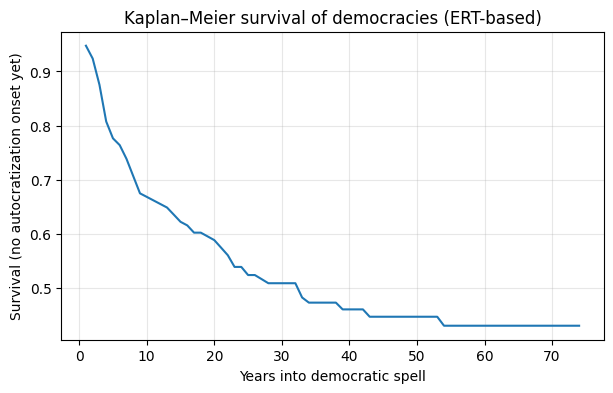

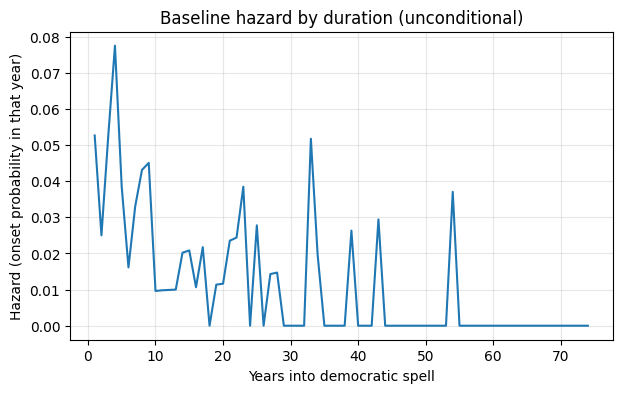

In [77]:
km = spell_summary.copy()
max_d = int(km["duration_years"].max())

rows = []
surv = 1.0
for d in range(1, max_d + 1):
    at_risk = int((km["duration_years"] >= d).sum())
    events  = int(((km["duration_years"] == d) & (km["event"] == 1)).sum())
    if at_risk == 0:
        break
    hazard = events / at_risk
    surv *= (1 - hazard)
    rows.append((d, at_risk, events, hazard, surv))

km_table = pd.DataFrame(rows, columns=["duration_years","at_risk","events","hazard","survival"])
display(km_table.head(20))

plt.figure(figsize=(7,4))
plt.plot(km_table["duration_years"], km_table["survival"])
plt.xlabel("Years into democratic spell")
plt.ylabel("Survival (no autocratization onset yet)")
plt.title("Kaplan–Meier survival of democracies (ERT-based)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(km_table["duration_years"], km_table["hazard"])
plt.xlabel("Years into democratic spell")
plt.ylabel("Hazard (onset probability in that year)")
plt.title("Baseline hazard by duration (unconditional)")
plt.grid(True, alpha=0.3)
plt.show()


## 7) Feature engineering: lags + changes + rolling mean/std (no leakage)
Rolling stats are computed on **lagged** values (t−1..), avoiding leakage.


In [78]:
BASE_FEATURES = [
    "inflation_surprise",
    "unemployment",
    "gdp_growth",
    "consumption_pc_growth",
    "gini",
    "debt_service_exports",
    "ext_debt_gni",
    "resource_rents_gdp",
    "urban_share",
    "youth_share_1524",
    "youth_unemployment",
    "net_migration_per_1000",
]

# Ensure columns exist even if WB missing some indicator entirely
for f in BASE_FEATURES:
    if f not in risk.columns:
        risk[f] = np.nan

risk = risk.sort_values(["country_key","year"]).copy()

for f in BASE_FEATURES:
    risk[f + "_lag1"] = risk.groupby("country_key")[f].shift(1)
    risk[f + "_lag2"] = risk.groupby("country_key")[f].shift(2)
    risk[f + "_chg1"] = risk[f + "_lag1"] - risk[f + "_lag2"]

K = 5
for f in BASE_FEATURES:
    risk[f + "_rollmean5"] = (
        risk.groupby("country_key")[f + "_lag1"]
            .transform(lambda s: s.rolling(K, min_periods=3).mean())
    )
    risk[f + "_rollstd5"] = (
        risk.groupby("country_key")[f + "_lag1"]
            .transform(lambda s: s.rolling(K, min_periods=3).std())
    )
    risk[f + "_accel"] = risk[f + "_lag1"] - risk[f + "_rollmean5"]

display(risk[[
    "country_key","year","event","t_in_spell",
    "inflation_surprise_lag1","inflation_surprise_chg1",
    "inflation_surprise_rollmean5","inflation_surprise_rollstd5","inflation_surprise_accel"
]].head(12))


,country_key,year,event,t_in_spell,inflation_surprise_lag1,inflation_surprise_chg1,inflation_surprise_rollmean5,inflation_surprise_rollstd5,inflation_surprise_accel
730,ALB,2005,0,0,NaN,NaN,NaN,NaN,NaN
731,ALB,2006,0,1,-0.371849,NaN,NaN,NaN,NaN
732,ALB,2007,0,2,-0.831015,-0.459166,NaN,NaN,NaN
733,ALB,2008,0,3,-0.121689,0.709326,-0.441518,0.359759,0.319829
734,ALB,2009,0,4,1.234068,1.355757,-0.022621,0.887796,1.256689
735,ALB,2010,0,5,-0.387254,-1.621322,-0.095548,0.785956,-0.291707
736,ALB,2011,0,6,0.975544,1.362798,0.173931,0.891447,0.801613
737,ALB,2012,0,7,0.524410,-0.451133,0.445016,0.693577,0.079395
738,ALB,2013,0,8,-1.083537,-1.607947,0.252646,0.968824,-1.336183
739,ALB,2014,0,9,-0.997291,0.086246,-0.193626,0.916221,-0.803665


## 8) Discrete-time hazard model (duration bins + engineered predictors)


In [79]:
haz = risk.copy()

haz["dur_bin"] = pd.cut(
    haz["t_in_spell"],
    bins=[-1, 2, 5, 10, 20, 50, 200],
    labels=["0-2", "3-5", "6-10", "11-20", "21-50", "51+"],
    ordered=True
)

PRED_COLS = [
    "inflation_surprise_rollmean5", "inflation_surprise_chg1", "inflation_surprise_rollstd5",
    "unemployment_rollmean5", "unemployment_chg1",
    "consumption_pc_growth_rollmean5", "consumption_pc_growth_chg1",

    "gini_rollmean5",
    "debt_service_exports_rollmean5", "debt_service_exports_chg1",
    "ext_debt_gni_rollmean5",

    "resource_rents_gdp_rollmean5",
    "urban_share_rollmean5",
    "youth_share_1524_rollmean5",
    "youth_unemployment_rollmean5",
    "net_migration_per_1000_rollmean5",
]

# Some are sparse: add missingness flags and short ffill (within-country)
SPARSE = [
    "gini_rollmean5",
    "ext_debt_gni_rollmean5",
    "debt_service_exports_rollmean5",
    "resource_rents_gdp_rollmean5",
    "youth_unemployment_rollmean5",
    "net_migration_per_1000_rollmean5",
]

haz = haz.sort_values(["country_key","year"]).copy()

for col in SPARSE:
    haz[col + "_missing"] = haz[col].isna().astype(int)
    haz[col] = haz.groupby("country_key")[col].transform(lambda s: s.ffill(limit=5))

FINAL_PRED = PRED_COLS + [c + "_missing" for c in SPARSE]

haz_model = (
    haz[["country_key","year","event","dur_bin"] + FINAL_PRED]
    .replace([np.inf, -np.inf], np.nan)
)

# Keep rows with defined duration bins; other missingness handled by imputation in pipeline.
haz_model = haz_model[haz_model["dur_bin"].notna()].copy()

print("Hazard modeling rows:", haz_model.shape)
print("Event rate:", float(haz_model["event"].mean()))
display(haz_model.head())


Hazard modeling rows: (4351, 26)
Event rate: 0.019305906688117675


,country_key,year,event,dur_bin,inflation_surprise_rollmean5,inflation_surprise_chg1,inflation_surprise_rollstd5,unemployment_rollmean5,unemployment_chg1,consumption_pc_growth_rollmean5,...,urban_share_rollmean5,youth_share_1524_rollmean5,youth_unemployment_rollmean5,net_migration_per_1000_rollmean5,gini_rollmean5_missing,ext_debt_gni_rollmean5_missing,debt_service_exports_rollmean5_missing,resource_rents_gdp_rollmean5_missing,youth_unemployment_rollmean5_missing,net_migration_per_1000_rollmean5_missing
730,ALB,2005,0,0-2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,1,1,1,1,1
731,ALB,2006,0,0-2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,1,1,1,1,1
732,ALB,2007,0,0-2,NaN,-0.459166,NaN,NaN,-0.340,NaN,...,NaN,NaN,NaN,NaN,1,1,1,1,1,1
733,ALB,2008,0,3-5,-0.441518,0.709326,0.359759,15.852667,0.340,10.102431,...,47.088715,17.839027,26.2550,-16.442520,1,0,0,0,0,0
734,ALB,2009,0,3-5,-0.022621,1.355757,0.887796,15.154500,-2.906,10.619107,...,47.662803,17.876857,26.3425,-16.625546,1,0,0,0,0,0


## 9) Train/test split (time split), evaluate logistic hazard model


In [80]:
TRAIN_END = 2010
train_mask = haz_model["year"] <= TRAIN_END
test_mask  = haz_model["year"] >  TRAIN_END

def precision_at_k(y_true, scores, Ks=(25,50,100,200)):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    order = np.argsort(-scores)
    base = y_true.mean()
    rows = []
    for K in Ks:
        if K <= len(y_true):
            prec = y_true[order[:K]].mean()
            rows.append((K, float(prec), float(prec/base) if base > 0 else np.nan))
    return pd.DataFrame(rows, columns=["K","precision","lift_vs_base"])

def fit_eval(include_country: bool):
    y = haz_model["event"].astype(int).values

    if include_country:
        X = haz_model.drop(columns=["event","year"]).copy()
        cat_cols = ["dur_bin", "country_key"]
    else:
        X = haz_model.drop(columns=["event","year","country_key"]).copy()
        cat_cols = ["dur_bin"]

    num_cols = [c for c in X.columns if c not in cat_cols]

    cat_pre = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    num_pre = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("cat", cat_pre, cat_cols),
            ("num", num_pre, num_cols),
        ],
        remainder="drop"
    )

    clf = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))
    ])

    clf.fit(X[train_mask], y[train_mask])
    p = clf.predict_proba(X[test_mask])[:,1]
    y_test = y[test_mask]

    out = {
        "include_country": include_country,
        "pos_rate": float(y_test.mean()),
        "ROC_AUC": float(roc_auc_score(y_test, p)) if len(np.unique(y_test)) > 1 else np.nan,
        "PR_AUC": float(average_precision_score(y_test, p)) if len(np.unique(y_test)) > 1 else np.nan,
        "Brier": float(brier_score_loss(y_test, p)),
    }
    pk = precision_at_k(y_test, p)
    return clf, X, y, p, y_test, out, pk

clf_no_cty, X_no, y_all, p_no, y_test, res_no, pk_no = fit_eval(False)
clf_cty,    X_cty, _,     p_cty, _,      res_cty, pk_cty = fit_eval(True)

print("No country FE:", res_no)
display(pk_no)

print("With country FE:", res_cty)
display(pk_cty)


No country FE: {'include_country': False, 'pos_rate': 0.02729528535980149, 'ROC_AUC': 0.7059626881055452, 'PR_AUC': 0.04698062050509451, 'Brier': 0.224405463387955}


,K,precision,lift_vs_base
0,25,0.000,0.000000
1,50,0.020,0.732727
2,100,0.040,1.465455
3,200,0.055,2.015000


With country FE: {'include_country': True, 'pos_rate': 0.02729528535980149, 'ROC_AUC': 0.6881699649556792, 'PR_AUC': 0.04934967722762036, 'Brier': 0.14791895968329186}


,K,precision,lift_vs_base
0,25,0.00,0.000000
1,50,0.04,1.465455
2,100,0.06,2.198182
3,200,0.04,1.465455


### Calibrate main model (use No country FE by default)


In [81]:
clf_main = clf_no_cty
X_main   = X_no
p_main   = p_no

cal_main = CalibratedClassifierCV(clf_main, method="isotonic", cv=5)
cal_main.fit(X_main[train_mask], y_all[train_mask])
p_main_cal = cal_main.predict_proba(X_main[test_mask])[:,1]

metrics_main_uncal = {
    "Test positive rate": float(y_test.mean()),
    "ROC_AUC": float(roc_auc_score(y_test, p_main)) if len(np.unique(y_test)) > 1 else np.nan,
    "PR_AUC": float(average_precision_score(y_test, p_main)) if len(np.unique(y_test)) > 1 else np.nan,
    "Brier": float(brier_score_loss(y_test, p_main)),
}
metrics_main_cal = {
    "Test positive rate": float(y_test.mean()),
    "ROC_AUC": float(roc_auc_score(y_test, p_main_cal)) if len(np.unique(y_test)) > 1 else np.nan,
    "PR_AUC": float(average_precision_score(y_test, p_main_cal)) if len(np.unique(y_test)) > 1 else np.nan,
    "Brier": float(brier_score_loss(y_test, p_main_cal)),
}

print("Main model (uncal):", metrics_main_uncal)
print("Main model (cal):  ", metrics_main_cal)

print("\nUncalibrated Precision@K")
display(precision_at_k(y_test, p_main))

print("\nCalibrated Precision@K")
display(precision_at_k(y_test, p_main_cal))


Main model (uncal): {'Test positive rate': 0.02729528535980149, 'ROC_AUC': 0.7059626881055452, 'PR_AUC': 0.04698062050509451, 'Brier': 0.224405463387955}
Main model (cal):   {'Test positive rate': 0.02729528535980149, 'ROC_AUC': 0.7047515976087405, 'PR_AUC': 0.04743693043861204, 'Brier': 0.02634320654659016}

Uncalibrated Precision@K


,K,precision,lift_vs_base
0,25,0.000,0.000000
1,50,0.020,0.732727
2,100,0.040,1.465455
3,200,0.055,2.015000



Calibrated Precision@K


,K,precision,lift_vs_base
0,25,0.040,1.465455
1,50,0.020,0.732727
2,100,0.020,0.732727
3,200,0.055,2.015000


### Country concentration among top alerts (main calibrated model)


In [82]:
top = haz_model[test_mask].copy()
top["score"] = p_main_cal
top50 = top.sort_values("score", ascending=False).head(50)
display(top50["country_key"].value_counts().head(20))


country_key
MWI    5
NPL    4
TLS    4
MLI    4
MDA    4
KEN    4
NER    4
GNB    3
BOL    3
NGA    3
ARM    2
CPV    2
ZMB    2
SLB    2
FJI    1
HND    1
SLE    1
XKX    1
Name: count, dtype: int64

## 10) Marginal hazard curves: simulate effects across duration bins


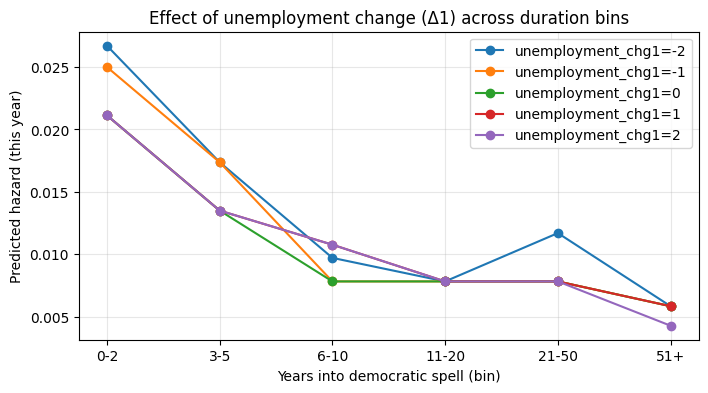

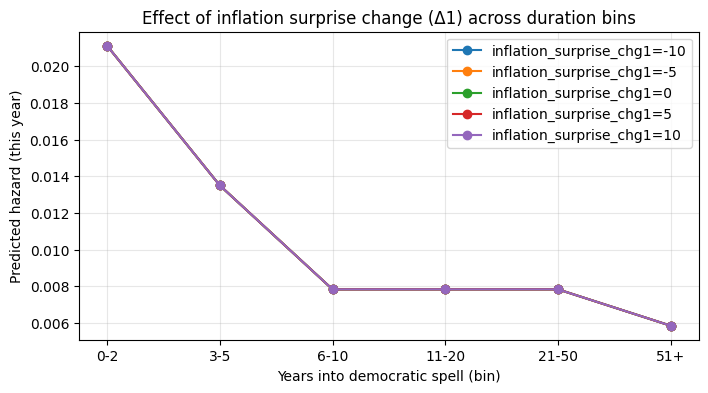

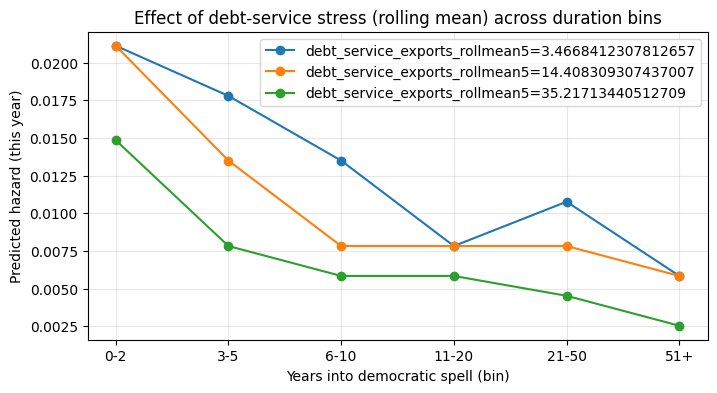

,inflation_surprise_rollmean5,inflation_surprise_chg1,inflation_surprise_rollstd5,unemployment_rollmean5,unemployment_chg1,consumption_pc_growth_rollmean5,consumption_pc_growth_chg1,gini_rollmean5,debt_service_exports_rollmean5,debt_service_exports_chg1,...,youth_unemployment_rollmean5,net_migration_per_1000_rollmean5,gini_rollmean5_missing,ext_debt_gni_rollmean5_missing,debt_service_exports_rollmean5_missing,resource_rents_gdp_rollmean5_missing,youth_unemployment_rollmean5_missing,net_migration_per_1000_rollmean5_missing,dur_bin,pred_hazard
0,-0.2834,0.341738,2.151476,6.9182,-2,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,0-2,0.026709
1,-0.2834,0.341738,2.151476,6.9182,-1,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,0-2,0.025001
2,-0.2834,0.341738,2.151476,6.9182,0,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,0-2,0.021128
3,-0.2834,0.341738,2.151476,6.9182,1,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,0-2,0.021128
4,-0.2834,0.341738,2.151476,6.9182,2,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,0-2,0.021128
5,-0.2834,0.341738,2.151476,6.9182,-2,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,3-5,0.017372
6,-0.2834,0.341738,2.151476,6.9182,-1,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,3-5,0.017372
7,-0.2834,0.341738,2.151476,6.9182,0,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,3-5,0.013500
8,-0.2834,0.341738,2.151476,6.9182,1,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,3-5,0.013500
9,-0.2834,0.341738,2.151476,6.9182,2,2.105599,-0.006738,33.936667,14.408309,-0.012185,...,14.9946,0.059872,1.0,1.0,1.0,0.0,0.0,0.0,3-5,0.013500


In [83]:
X_full = X_main.copy()

dur_levels = ["0-2","3-5","6-10","11-20","21-50","51+"]

# Median reference row (numeric predictors)
numeric_cols = [c for c in X_full.columns if c != "dur_bin"]
med = X_full[numeric_cols].median().to_dict()

def simulate_curve(var, values, use_calibrated=True):
    rows = []
    for d in dur_levels:
        for v in values:
            row = med.copy()
            row["dur_bin"] = d
            row[var] = v
            rows.append(row)
    sim = pd.DataFrame(rows)
    model = cal_main if use_calibrated else clf_main
    sim["pred_hazard"] = model.predict_proba(sim)[:,1]
    return sim

sim_unemp = simulate_curve("unemployment_chg1", values=[-2, -1, 0, 1, 2])
sim_infl  = simulate_curve("inflation_surprise_chg1", values=[-10, -5, 0, 5, 10])

# If this column is all-NaN in haz_model, percentiles will error — guard it:
if haz_model["debt_service_exports_rollmean5"].notna().any():
    vals = list(np.nanpercentile(haz_model["debt_service_exports_rollmean5"], [10,50,90]))
else:
    vals = [0, 0, 0]
sim_debt  = simulate_curve("debt_service_exports_rollmean5", values=vals)

def plot_sim(sim, var, title):
    plt.figure(figsize=(8,4))
    for v in sorted(sim[var].unique()):
        tmp = sim[sim[var] == v]
        plt.plot(tmp["dur_bin"], tmp["pred_hazard"], marker="o", label=f"{var}={v}")
    plt.xlabel("Years into democratic spell (bin)")
    plt.ylabel("Predicted hazard (this year)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_sim(sim_unemp, "unemployment_chg1", "Effect of unemployment change (Δ1) across duration bins")
plot_sim(sim_infl,  "inflation_surprise_chg1", "Effect of inflation surprise change (Δ1) across duration bins")
plot_sim(sim_debt,  "debt_service_exports_rollmean5", "Effect of debt-service stress (rolling mean) across duration bins")

display(sim_unemp.head(12))


## 11) Timing summaries from KM table


In [84]:
median_time = km_table.loc[km_table["survival"] <= 0.5, "duration_years"].min()
print("Median years until onset (if reached):", median_time)

def time_to_survival(s_target):
    hit = km_table.loc[km_table["survival"] <= s_target, "duration_years"]
    return int(hit.min()) if len(hit) else None

for s in [0.9, 0.8, 0.7, 0.6]:
    print(f"Years until survival <= {s:.1f}:", time_to_survival(s))

top_hazard = km_table.sort_values("hazard", ascending=False).head(10)
display(top_hazard)


Median years until onset (if reached): 33
Years until survival <= 0.9: 3
Years until survival <= 0.8: 5
Years until survival <= 0.7: 9
Years until survival <= 0.6: 19


,duration_years,at_risk,events,hazard,survival
3,4,142,11,0.077465,0.807575
0,1,171,9,0.052632,0.947368
2,3,153,8,0.052288,0.875387
32,33,58,3,0.051724,0.482897
8,9,111,5,0.045045,0.675050
7,8,116,5,0.043103,0.706892
4,5,130,5,0.038462,0.776515
22,23,78,3,0.038462,0.539308
53,54,27,1,0.037037,0.430841
6,7,121,4,0.033058,0.738734


## 12) Next upgrades
- Add commodity price shocks (oil, food) and terms-of-trade shocks.
- Add interaction terms (stress × inequality).
- Consider outcome horizon: onset within 2–3 years (often more practical).
- Robust evaluation: GroupKFold by country for generalization checks.
